# Figure 5. Two-pass image reconstruction results

Reproduces Figure 5 (§5.2.2) of *A Spectrally Damped Tensor Randomized
Kaczmarz Method for Doubly Noisy Tensor Systems*.

- **Experiment 5.2.2** — two-pass Geisel Library image deblurring comparison between standard TRK
  and SD-TRK (`Fig5.pdf`)

**Common setting.** $\mathcal{X}^{\mathrm{true}}$ is an RGB image of the Geisel Library at UC San
Diego, resized and normalized to $[0,1]$, of size $256\times170\times3$. Row/column Gaussian blur
matrices $A^r_{\mathrm{mat}}, A^c_{\mathrm{mat}}$ (standard deviation $2.0$, truncation radius $8$)
are embedded in the **first frontal slice** of t-product operators (remaining slices zero) — so all
Fourier frontal slices coincide and a fixed **scalar** damping $\lambda$ is the natural choice.
The blurred image is generated with the noise-free operators and contaminated with observation
noise,

$$\tilde{\mathcal{B}}=\left(\mathcal{A}^{c}(\mathcal{A}^{r}\mathcal{X}^{\mathrm{true}})^{\top_{12}}\right)^{\top_{12}}+\delta_B\,\mathcal{G}^{B},$$

with pixel values clipped to $[0,1]$; the algorithms are supplied with the **perturbed observed
operators** $\tilde{\mathcal{A}}^r, \tilde{\mathcal{A}}^c$ (first slices $A_{\mathrm{mat}}+\delta_A G_{\mathrm{mat}}$),
so $\delta_A$ creates an operator mismatch as in the doubly noisy model; $\delta_A=10^{-4}$,
$\delta_B=10^{-2}$. Recovery proceeds in two directional passes — the row system
$\tilde{\mathcal{A}}^{r}\mathcal{X}=\tilde{\mathcal{B}}$, then the column system
$\tilde{\mathcal{A}}^{c}\mathcal{Y}=(\mathcal{X}^{\mathrm{row}})^{\top_{12}}$, with
$\mathcal{X}^{\mathrm{rec}}=\mathcal{Y}^{\top_{12}}$ — each pass initialized from its degraded
observation. **SD-TRK** uses $\omega=0.30$, $\lambda=10^{-2}$, and $1200$ iterations per pass; the
**standard TRK** baseline is the same solver with $\omega=1$, $\lambda=0$. Quality is measured by
relative error $\|\mathcal{Z}-\mathcal{X}^{\mathrm{true}}\|_F/\|\mathcal{X}^{\mathrm{true}}\|_F$
and PSNR.

**Expected result (Table 2).** Degraded $0.1289$ / $22.5856$ dB; standard TRK $0.1246$ /
$22.8824$ dB; SD-TRK $\mathbf{0.1025}$ / $\mathbf{24.5723}$ dB — SD-TRK achieves the lowest
relative error and the highest PSNR under the same two-pass reconstruction procedure.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'ps.fonttype': 42,
})


In [2]:
def load_image(path, maxside):
    # RGB image resized so max(height, width) = maxside, normalized to [0, 1]
    img = Image.open(path).convert('RGB')
    scale = maxside / max(img.size)
    if scale < 1.0:
        img = img.resize((max(1, round(img.size[0] * scale)),
                          max(1, round(img.size[1] * scale))), Image.Resampling.LANCZOS)
    return np.asarray(img, dtype=np.float64) / 255.0


def blur_matrix(n, sigma, radius):
    # 1D Gaussian blur matrix with reflexive boundary conditions
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-offsets**2 / (2.0 * sigma**2))
    kernel /= kernel.sum()
    M = np.zeros((n, n))
    for i in range(n):
        for off, w in zip(offsets, kernel):
            j = i + int(off)
            if j < 0:
                j = -j
            if j >= n:
                j = 2 * n - j - 2
            M[i, j] += w
    return M


def embed(M, n3=3):
    # embed a matrix as a t-product operator: first frontal slice = M, rest zero
    A = np.zeros((*M.shape, n3))
    A[:, :, 0] = M
    return A


def t_prod(A, B):
    # t-product: FFT along mode 3 -> slice-wise matmul -> inverse FFT (Appendix A)
    n1, _, n3 = A.shape
    n4 = B.shape[1]
    A_hat = np.fft.fft(A, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    C_hat = np.zeros((n1, n4, n3), dtype=complex)
    for k in range(n3):
        C_hat[:, :, k] = A_hat[:, :, k] @ B_hat[:, :, k]
    return np.fft.ifft(C_hat, axis=2).real


def t12(Z):
    # Z^T12: transpose each frontal slice (swaps image row/column directions only,
    # NOT the t-product conjugate transpose)
    return np.transpose(Z, (1, 0, 2))


def relerr(Z, ref):
    return np.linalg.norm(Z - ref) / np.linalg.norm(ref)


def psnr(Z, ref):
    mse = np.mean((np.clip(Z, 0.0, 1.0) - ref)**2)
    return 10.0 * np.log10(1.0 / mse)


def sdtrk_solve(Aop, B, X0, omega, lam, seed):
    # row-action solver in the Fourier domain; standard TRK is the case omega=1, lam=0
    n1, _, n3 = Aop.shape
    A_hat = np.fft.fft(Aop, axis=2)
    B_hat = np.fft.fft(B, axis=2)
    X_hat = np.fft.fft(X0, axis=2)
    rowsq = np.array([np.linalg.norm(Aop[i])**2 for i in range(n1)])
    prob = rowsq / rowsq.sum()
    rng = np.random.default_rng(seed)
    for t in range(T):
        i = int(rng.choice(n1, p=prob))
        for k in range(n3):
            a = A_hat[i, :, k]
            denom = np.vdot(a, a).real + lam
            resid = a @ X_hat[:, :, k] - B_hat[i, :, k]
            X_hat[:, :, k] -= omega * np.outer(a.conj(), resid) / denom
    return np.clip(np.fft.ifft(X_hat, axis=2).real, 0.0, 1.0)

In [3]:
maxside = 256            # processed image: 256 x 170 x 3
sigma, radius = 2.0, 8   # Gaussian blur std and truncation radius
delta_A, delta_B = 1e-4, 1e-2
T = 1200                 # iterations per directional pass
omega, lam = 0.30, 1e-2  # SD-TRK relaxation and scalar damping
seed = 41


def two_pass(om, lm):
    # row-direction pass, then column-direction pass; X^rec = Y^T12
    # each pass starts from its degraded observation
    Xrow = sdtrk_solve(Ar, Btilde, Btilde, om, lm, seed + 100)
    Y = sdtrk_solve(Ac, t12(Xrow), t12(Xrow), om, lm, seed + 101)
    return t12(Y)

In [4]:
Xtrue = load_image(Path('geisel.jpg'), maxside)
height, width, _ = Xtrue.shape
print('processed size:', f'{width} x {height} x 3')

rng = np.random.default_rng(seed)
Armat = blur_matrix(height, sigma, radius)
Acmat = blur_matrix(width, sigma, radius)
Ar = embed(Armat + delta_A * rng.standard_normal(Armat.shape))  # observed A~^r for the solvers
Ac = embed(Acmat + delta_A * rng.standard_normal(Acmat.shape))  # observed A~^c for the solvers

# blur generated with the noise-free operators, then observation noise + clipping
Bblur = t12(t_prod(embed(Acmat), t12(t_prod(embed(Armat), Xtrue))))
Btilde = np.clip(Bblur + delta_B * rng.standard_normal(Bblur.shape), 0.0, 1.0)

Xtrk = two_pass(1.0, 0.0)     # standard TRK baseline
Xrec = two_pass(omega, lam)   # SD-TRK

print(f"{'Image':<28} {'Rel. error':>10} {'PSNR (dB)':>10}")
for name, Z in [('Degraded observation', Btilde), ('Standard TRK', Xtrk), ('SD-TRK', Xrec)]:
    print(f'{name:<28} {relerr(Z, Xtrue):>10.4f} {psnr(Z, Xtrue):>10.4f}')

processed size: 256 x 170 x 3
Image                        Rel. error  PSNR (dB)
Degraded observation             0.1289    22.5856
Standard TRK                     0.1246    22.8824
SD-TRK                           0.1025    24.5723


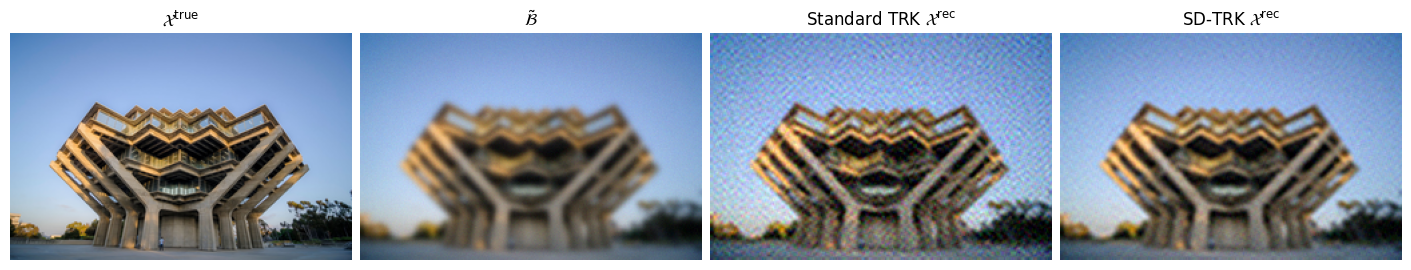

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), constrained_layout=True)
panels = [
    (Xtrue, r'$\mathcal{X}^{\mathrm{true}}$'),
    (Btilde, r'$\tilde{\mathcal{B}}$'),
    (Xtrk, r'Standard TRK $\mathcal{X}^{\mathrm{rec}}$'),
    (Xrec, r'SD-TRK $\mathcal{X}^{\mathrm{rec}}$'),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(np.clip(img, 0.0, 1.0))
    ax.axis('off')
plt.savefig('Fig5.pdf', dpi=600, bbox_inches='tight')
plt.show()